**Dataset:** `data/titanic.csv` (891 passengers). The placement columns of the original notebook are mapped to Titanic columns as described below.

Mapping: numeric features = all numeric columns except the identifier `PassengerId` and the label `Survived` (`Pclass, Age, SibSp, Parch, Fare`; Age is median-imputed). The silhouette sub-sample is capped at the number of rows (891).

"""
K-Means Clustering Workflow — Titanic Dataset (891 passengers)
==============================================================================
Pipeline:
  1. Load data and select NUMERICAL features only
  2. Impute missing values with the column MEDIAN
  3. Standardise features (zero mean, unit variance) with StandardScaler
  4. Fit K-Means for K = 2 .. 10 (random_state = 42)
  5. Plot the Elbow Curve (Inertia vs K) and the Silhouette Score Curve
  6. Select and record the optimal K
"""

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
DATA_PATH = "/Users/divyasaisomana/placement prediction system/data/titanic.csv"
K_RANGE = range(2, 11)                 # K = 2 .. 10 inclusive
SILHOUETTE_SAMPLE_SIZE = 5000          # sub-sample for tractable silhouette on 50k rows

In [2]:
# ----------------------------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------------------------
df = pd.read_csv("/Users/divyasaisomana/placement prediction system/data/titanic.csv")
print(f"Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")




Loaded dataset: 891 rows x 12 columns


In [3]:
# ----------------------------------------------------------------------------
# 2. SELECT NUMERICAL FEATURES
# ----------------------------------------------------------------------------
# All numeric-dtype columns, minus the row identifier and the label (PassengerId, Survived carries no
# descriptive signal about a passenger and would only add noise to distances).
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in ("PassengerId", "Survived")]

print(f"\nNumerical feature columns selected ({len(feature_cols)}):")
for c in feature_cols:
    print(f"  - {c}")

X_raw = df[feature_cols].copy()


Numerical feature columns selected (5):
  - Pclass
  - Age
  - SibSp
  - Parch
  - Fare


In [4]:

# ----------------------------------------------------------------------------
# 3. IMPUTE MISSING VALUES WITH THE COLUMN MEDIAN
# ----------------------------------------------------------------------------
missing_before = X_raw.isna().sum()
missing_before = missing_before[missing_before > 0]
print(f"\nColumns with missing values before imputation:")
print(missing_before.to_string())

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_raw), columns=feature_cols, index=X_raw.index
)
assert X_imputed.isna().sum().sum() == 0, "Imputation left missing values!"
print(f"\nMissing values after median imputation: {X_imputed.isna().sum().sum()}")




Columns with missing values before imputation:
Age    177

Missing values after median imputation: 0


In [5]:
# ----------------------------------------------------------------------------
# 4. STANDARDISE FEATURES
# ----------------------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
print(f"\nAfter StandardScaler -> mean ~ {X_scaled.mean():.4f}, std ~ {X_scaled.std():.4f}")




After StandardScaler -> mean ~ 0.0000, std ~ 1.0000


In [6]:
# ----------------------------------------------------------------------------
# 5. FIT K-MEANS FOR K = 2 .. 10  (seed = 42)
# ----------------------------------------------------------------------------
results = []
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_scaled), size=min(SILHOUETTE_SAMPLE_SIZE, len(X_scaled)), replace=False)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertia = km.inertia_
    # Silhouette on a fixed random sub-sample: exact silhouette needs an
    # O(n^2) pairwise-distance matrix, infeasible for n = 50,000 rows.
    sil = silhouette_score(X_scaled[sample_idx], labels[sample_idx])
    results.append({"K": k, "Inertia": inertia, "Silhouette": sil})
    print(f"K={k:2d}   Inertia={inertia:12,.1f}   Silhouette={sil:.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv("kmeans_k_selection_results.csv", index=False)



K= 2   Inertia=     3,323.6   Silhouette=0.3758
K= 3   Inertia=     2,462.2   Silhouette=0.4170
K= 4   Inertia=     2,053.8   Silhouette=0.4136
K= 5   Inertia=     1,701.0   Silhouette=0.4289
K= 6   Inertia=     1,499.4   Silhouette=0.4281
K= 7   Inertia=     1,328.3   Silhouette=0.4012


K= 8   Inertia=     1,203.9   Silhouette=0.4058


K= 9   Inertia=     1,101.7   Silhouette=0.3703
K=10   Inertia=       989.6   Silhouette=0.3808


In [7]:
best_k = results_df.loc[
    results_df["Silhouette"].idxmax(),
    "K"
]

print("Optimal K:", best_k)

Optimal K: 5


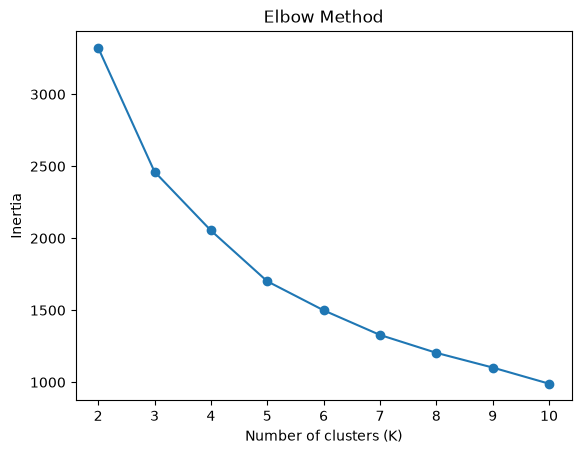

In [8]:
import matplotlib.pyplot as plt

plt.plot(
    results_df["K"],
    results_df["Inertia"],
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

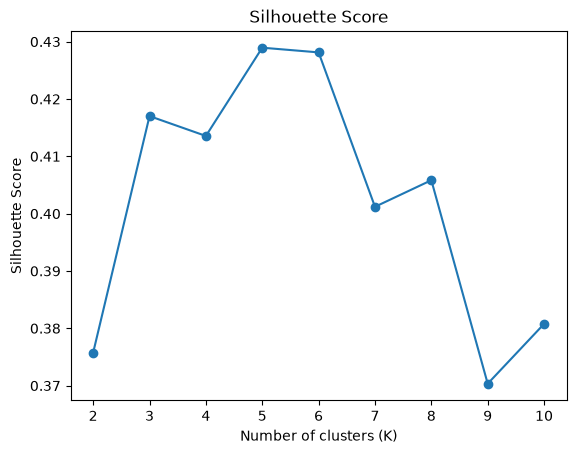

In [9]:
plt.plot(
    results_df["K"],
    results_df["Silhouette"],
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()